In [1]:
from path_config import PathConfig
import pandas as pd

# Yapılandırmayı başlat
config = PathConfig()

# Sayfa adı (daha okunur ve risksiz)
sheet_name = "Series Formatted Data"

# DL dosyalarını oku ve birleştir
df_dl = pd.concat(
    [
        pd.read_excel(config.dl_path, sheet_name=sheet_name),
        pd.read_excel(config.test_dl_path, sheet_name=sheet_name)
    ],
    ignore_index=True,
    join='outer'
)

# UL dosyalarını oku ve birleştir
df_ul = pd.concat(
    [
        pd.read_excel(config.ul_path, sheet_name=sheet_name),
        pd.read_excel(config.test_ul_path, sheet_name=sheet_name)
    ],
    ignore_index=True,
    join='outer'
)

# Scanner dosyalarını oku ve birleştir
df_scanner = pd.concat(
    [
        pd.read_excel(config.scanner_path, sheet_name=sheet_name),
        pd.read_excel(config.test_scanner_path, sheet_name=sheet_name)
    ],
    ignore_index=True,
    join='outer'
)

# Sütun isimlerini yazdır (kontrol için)
print("DL Columns:", df_dl.columns.tolist())
print("UL Columns:", df_ul.columns.tolist())
print("Scanner Columns:", df_scanner.columns.tolist())


DL Columns: ['Message', 'Time', 'Longitude', 'Latitude', 'Technology_Mode', 'NR_UE_PCI_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0', 'NR_UE_Nbr_PCI_0', 'NR_UE_Nbr_PCI_1', 'NR_UE_Nbr_PCI_2', 'NR_UE_Nbr_PCI_3', 'NR_UE_Nbr_PCI_4', 'NR_UE_Nbr_RSRP_0', 'NR_UE_Nbr_RSRP_1', 'NR_UE_Nbr_RSRP_2', 'NR_UE_Nbr_RSRP_3', 'NR_UE_Nbr_RSRP_4', 'NR_UE_Nbr_RSRQ_0', 'NR_UE_Nbr_RSRQ_1', 'NR_UE_Nbr_RSRQ_2', 'NR_UE_Nbr_RSRQ_3', 'NR_UE_Nbr_RSRQ_4', 'NR_UE_Timing_Advance', 'NR_UE_Pathloss_DL_0', 'NR_UE_Throughput_PDCP_DL', 'App_Throughput_DL', 'NR_UE_NACK_Rate_DL_0', 'NR_UE_Ack_As_Nack_DL_0', 'NR_UE_MCS_DL_0', 'NR_UE_RB_Num_DL_0', 'NR_UE_Modulation_Avg_DL_0', 'NR_UE_RI_DL_0', 'NR_UE_BLER_DL_0', 'NR_UE_CCE_AggregationLev_0', 'NR_UE_Power_Tx_PUSCH_0', 'NR_UE_Power_Tx_PRACH_0', 'NR_UE_NACK_Rate_UL_0', 'NR_UE_RACH_Attempt', 'NR_UE_RACH_OK', 'NR_UE_RACH_Fail', 'NR_UE_RACH_Procedure_Count', 'NR_UE_RRCReEstAttempt', 'NR_UE_RRCReEstFail', 'NR_UE_RRCReEst_EndResult', 'NR_UE_RRCConnectionAttempt', 'NR_UE_RRCConnect

/var/folders/01/_bgw0fxs5rv8ysw_gs46q0v40000gn/T/ipykernel_62228/1830151810.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap("tab20", len(unique_pci))


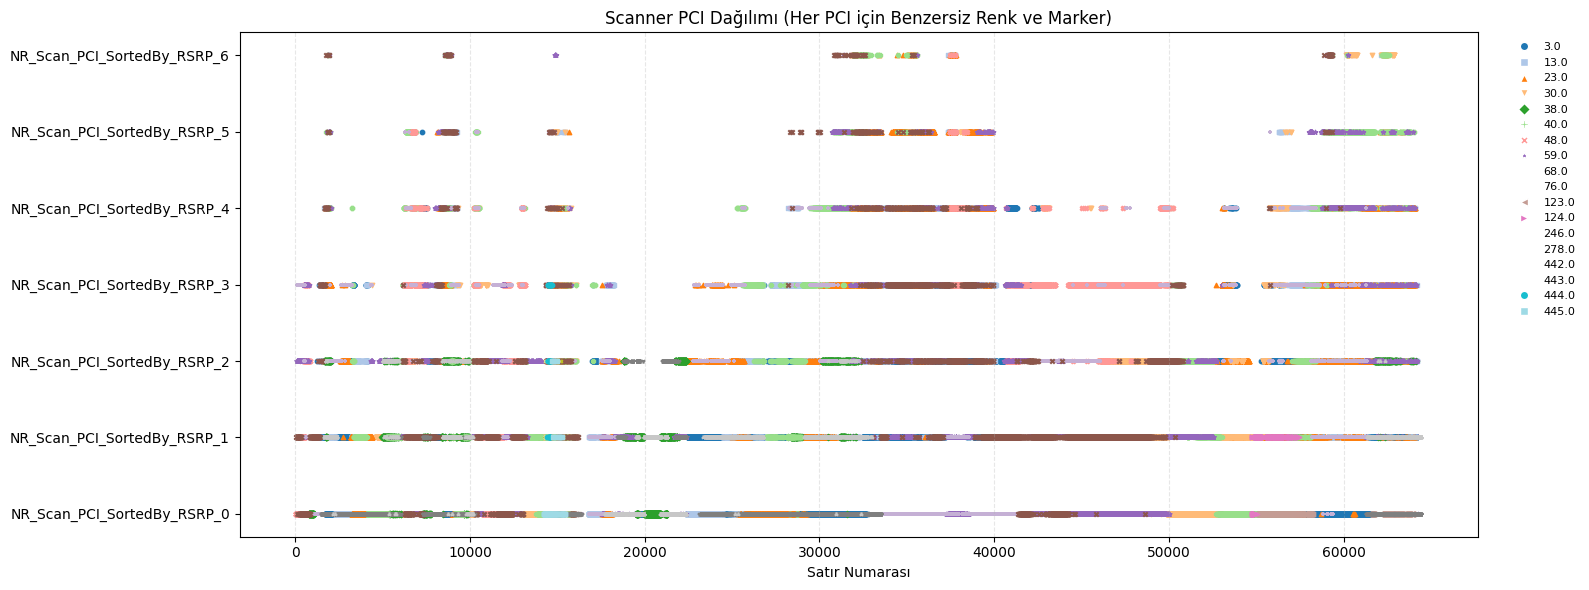

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1) Scanner PCI kolonları
pci_cols = [
    "NR_Scan_PCI_SortedBy_RSRP_0", "NR_Scan_PCI_SortedBy_RSRP_1", "NR_Scan_PCI_SortedBy_RSRP_2",
    "NR_Scan_PCI_SortedBy_RSRP_3", "NR_Scan_PCI_SortedBy_RSRP_4", "NR_Scan_PCI_SortedBy_RSRP_5",
    "NR_Scan_PCI_SortedBy_RSRP_6"
]
pci_cols = [c for c in pci_cols if c in df_scanner.columns]

# 2) Benzersiz PCI’lar
unique_pci = pd.unique(df_scanner[pci_cols].values.ravel())
unique_pci = [v for v in unique_pci if not pd.isna(v)]

# 3) Renk + marker havuzu
base_cmap = plt.cm.get_cmap("tab20", len(unique_pci))
markers   = ['o', 's', '^', 'v', 'D', 'P', 'X', '*', '+', 'x', '<', '>', '1', '2', '3', '4']

pci_style = {
    pci: (base_cmap(i % base_cmap.N), markers[i % len(markers)])
    for i, pci in enumerate(sorted(unique_pci))
}

# 4) Scatter plot
plt.figure(figsize=(16, 6))

for row_idx, col in enumerate(pci_cols):
    col_data = df_scanner[col]
    for pci_val, (color, marker) in pci_style.items():
        idx = col_data.index[col_data == pci_val]
        if len(idx) > 0:
            plt.scatter(idx, [row_idx] * len(idx), color=color, marker=marker, s=10)

# 5) Legend hazırlığı
handles = [
    plt.Line2D([0], [0], marker=m, color='w',
               markerfacecolor=c, markersize=6, label=str(p))
    for p, (c, m) in pci_style.items()
]

plt.legend(handles=handles,
           bbox_to_anchor=(1.02, 1),  # grafiğin sağ dışı
           loc='upper left',
           fontsize=8,
           frameon=False,
           ncol=1)  # Tek sütun; çoksa artır

# 6) Eksen ve başlık
plt.yticks(range(len(pci_cols)), pci_cols)
plt.xlabel("Satır Numarası")
plt.title("Scanner PCI Dağılımı (Her PCI için Benzersiz Renk ve Marker)")
plt.grid(True, axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


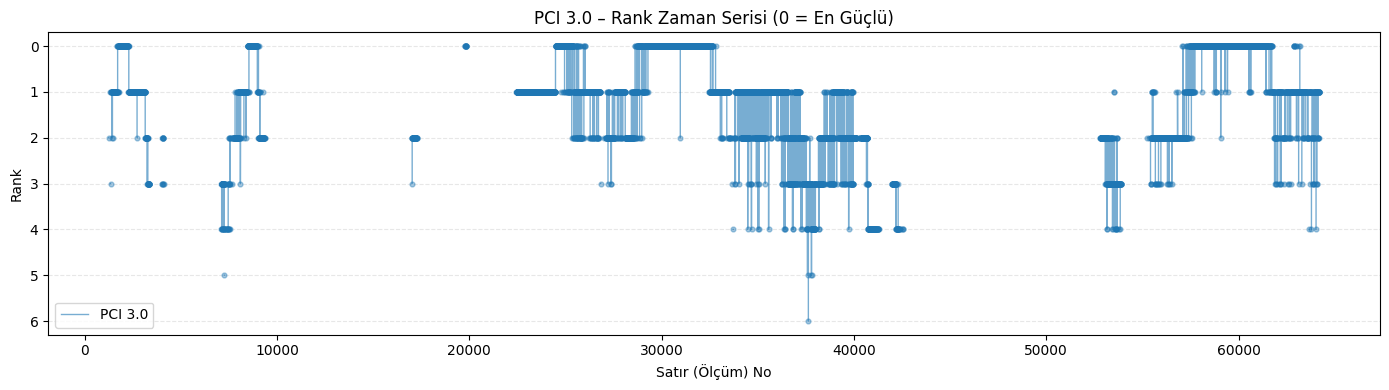

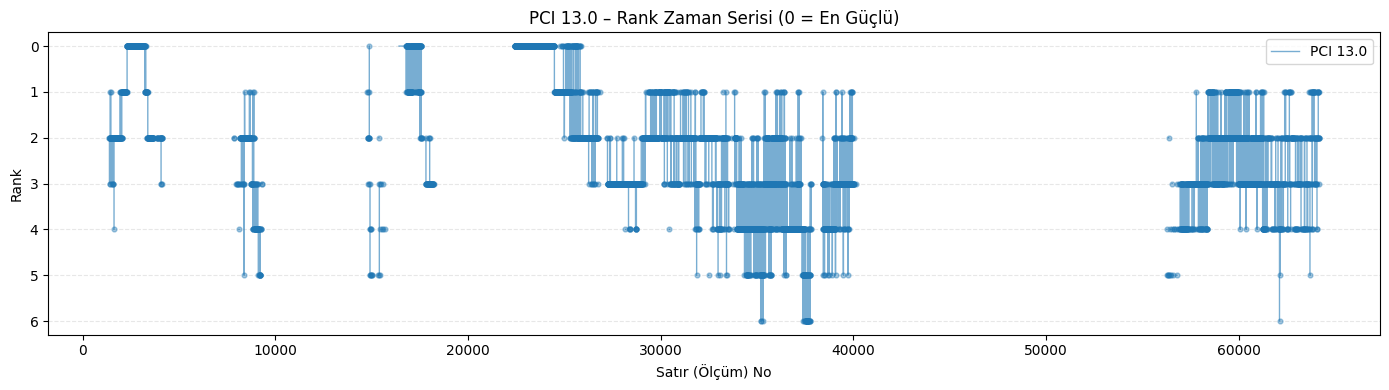

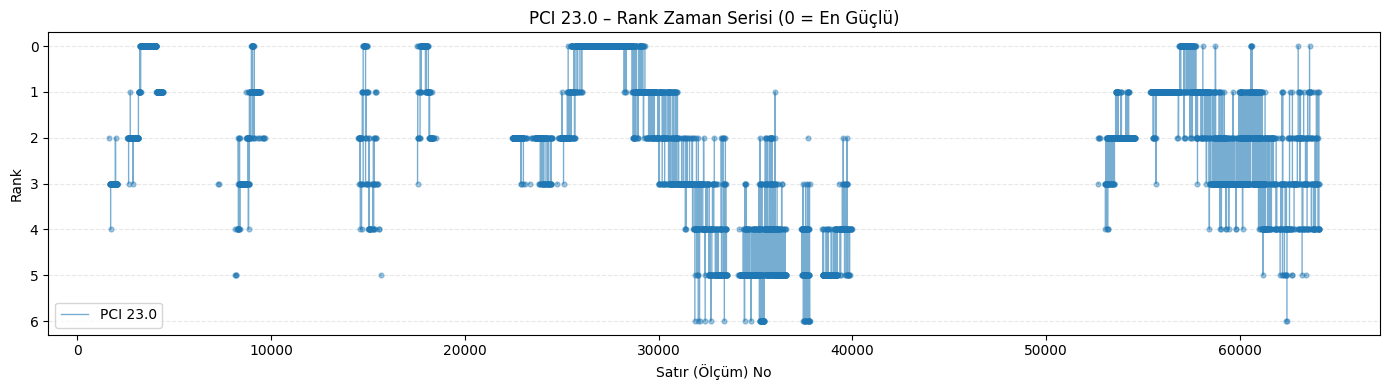

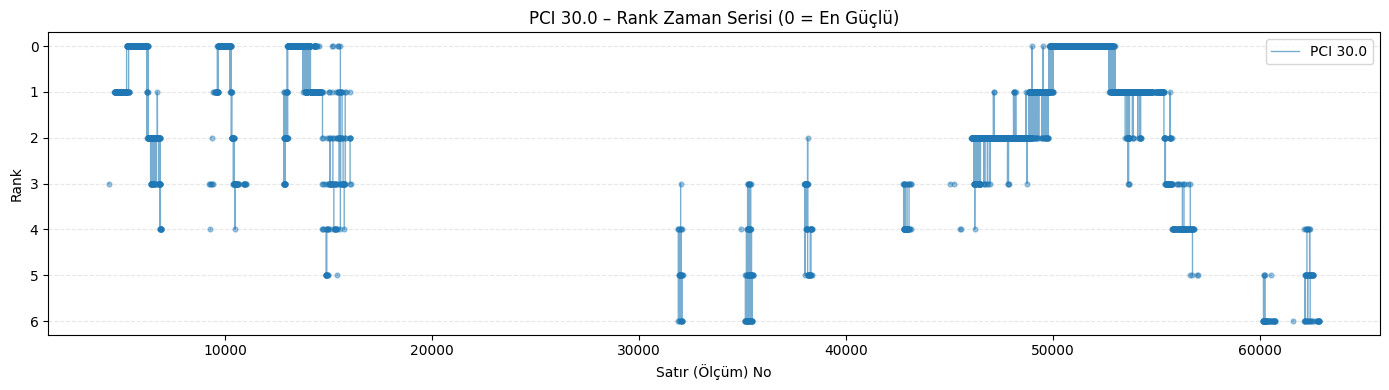

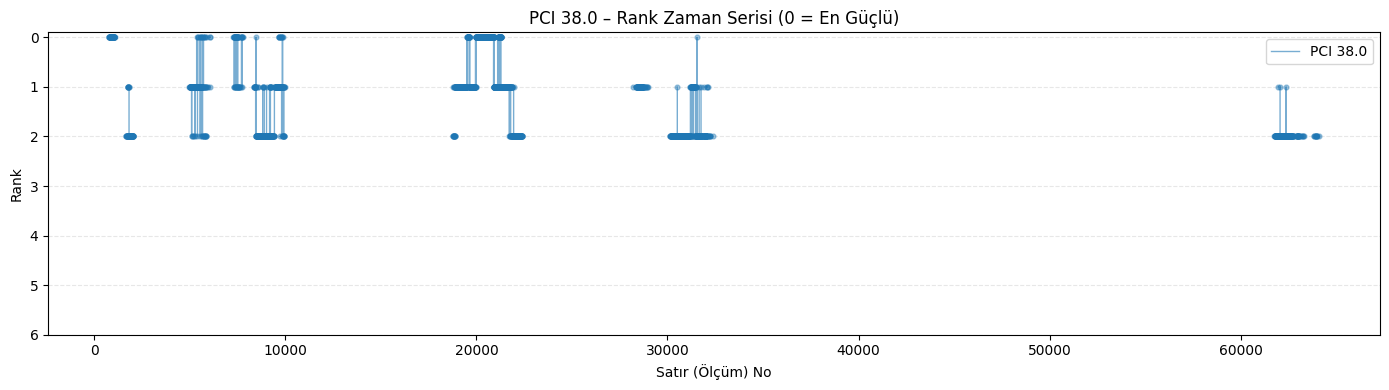

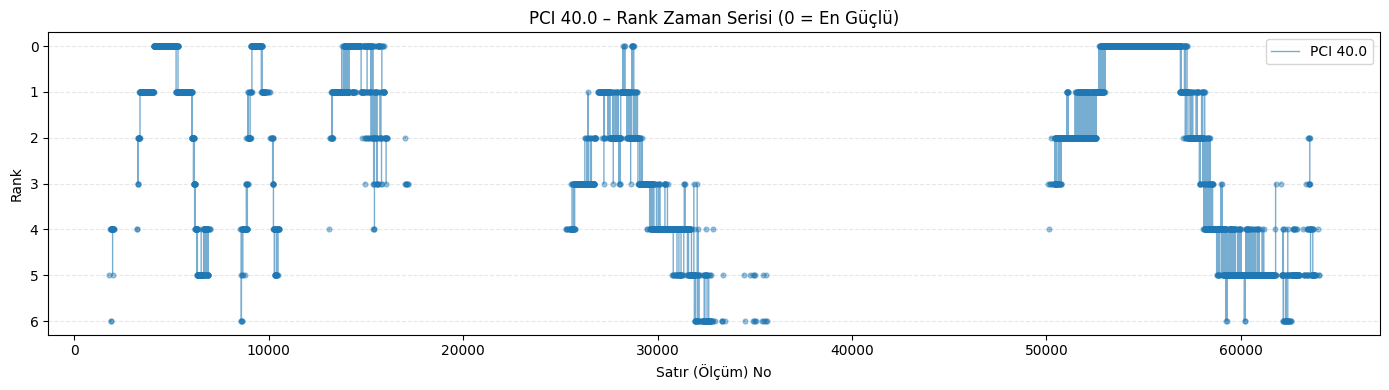

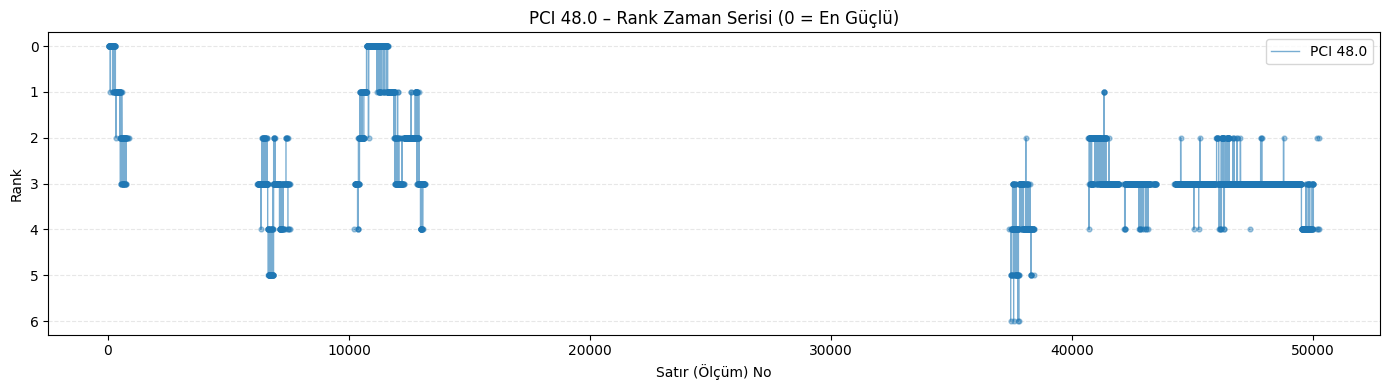

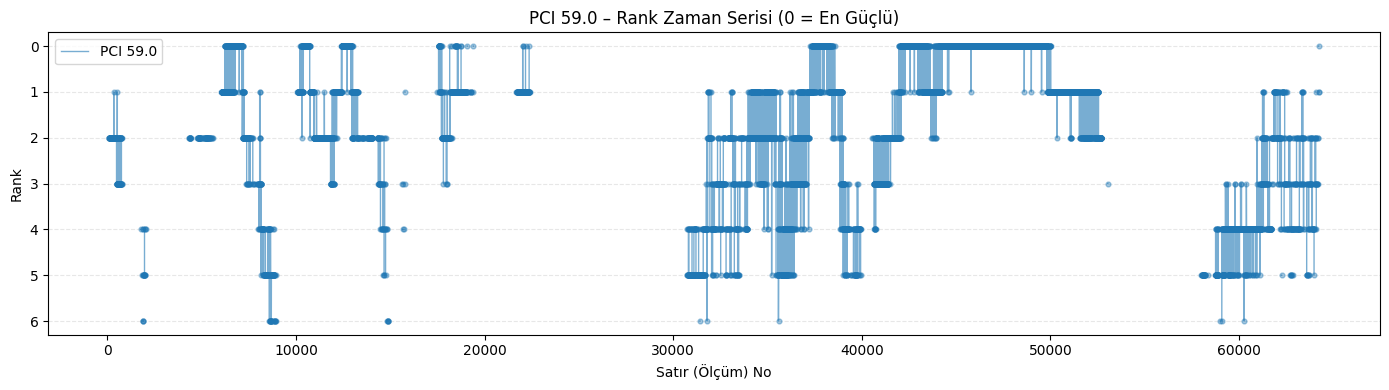

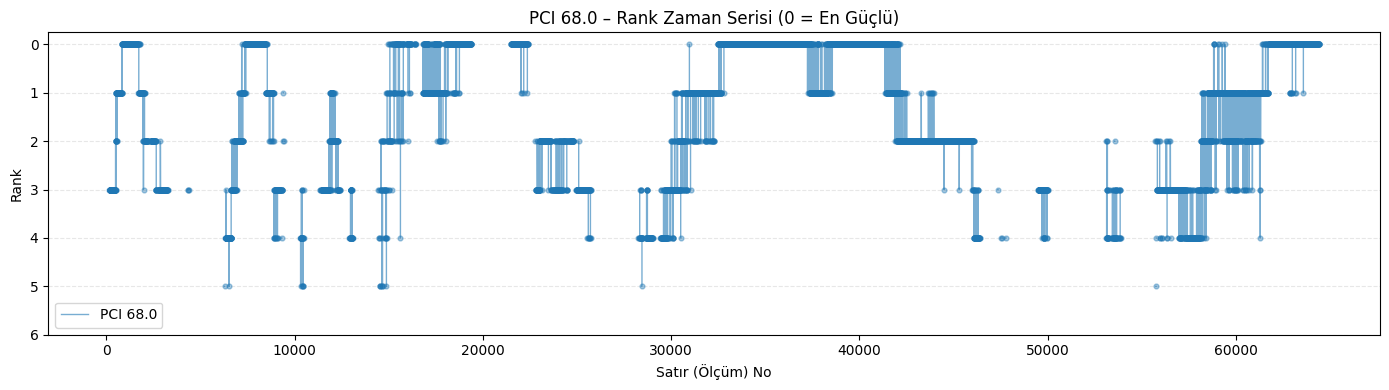

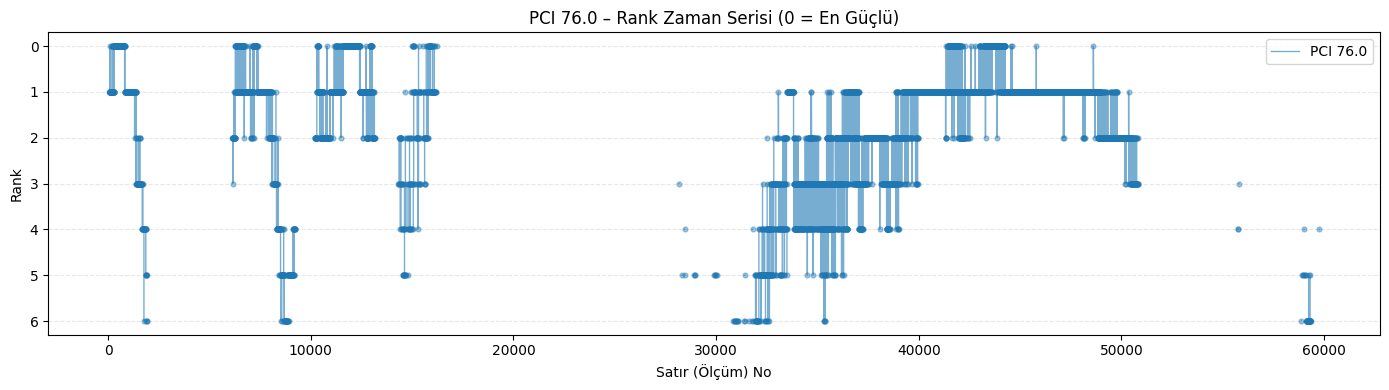

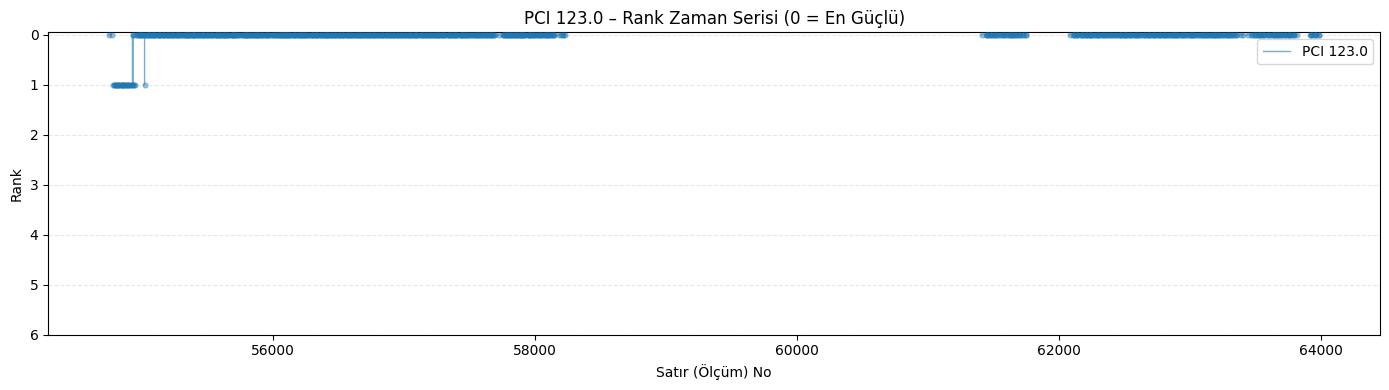

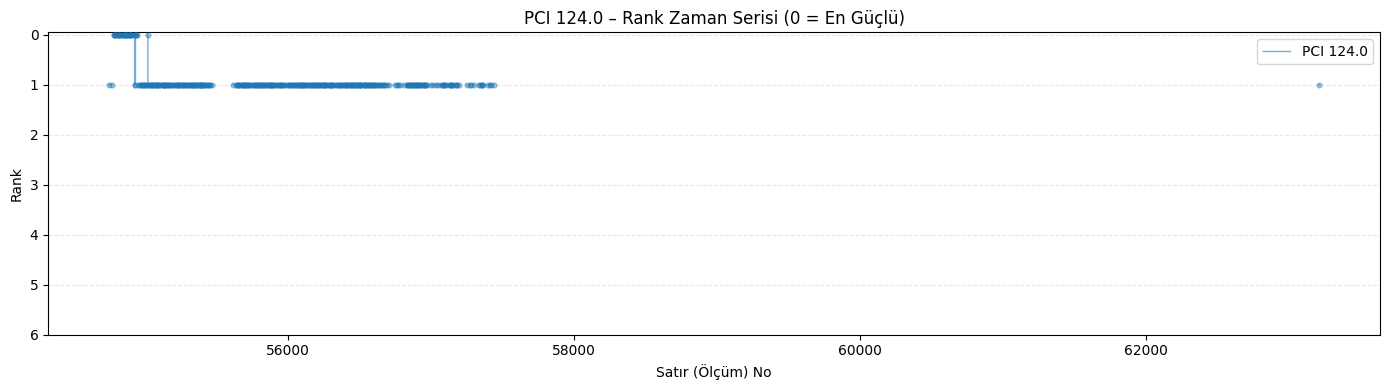

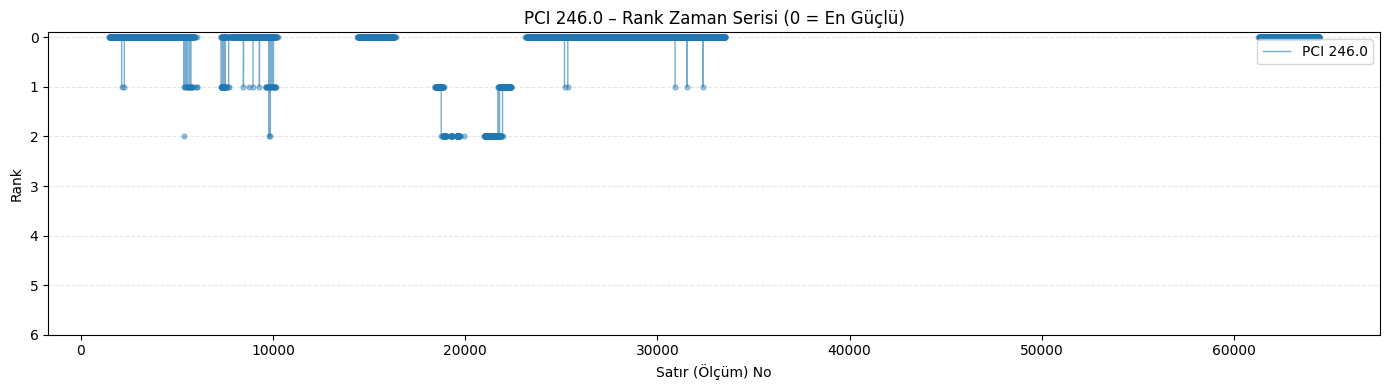

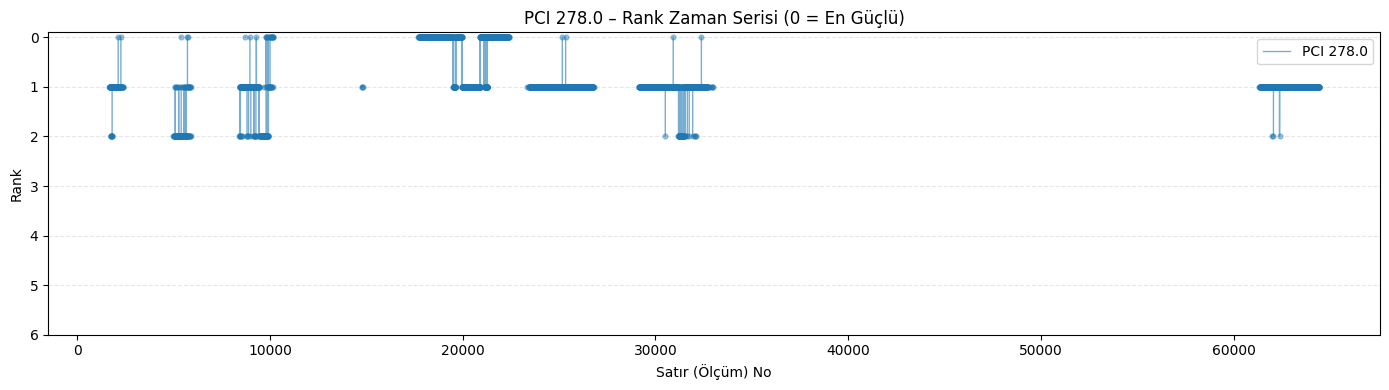

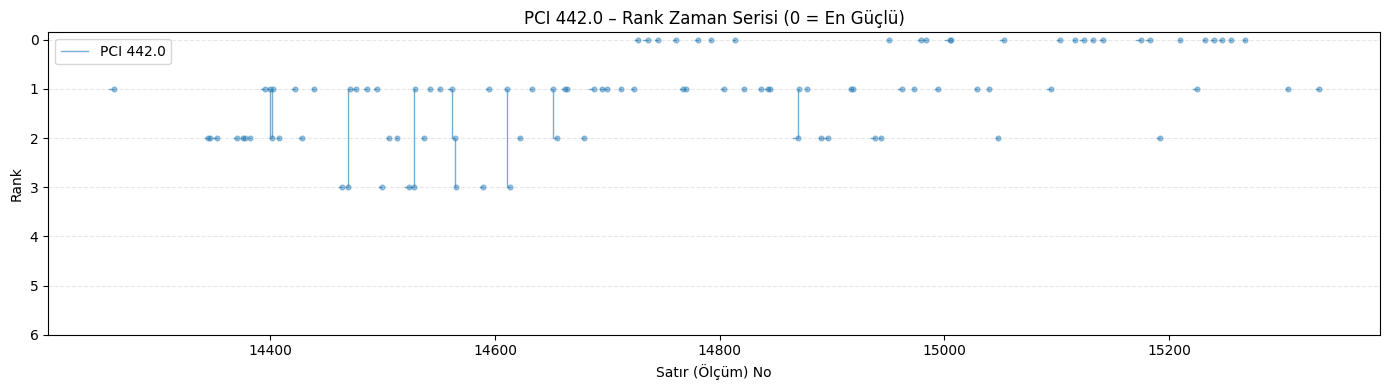

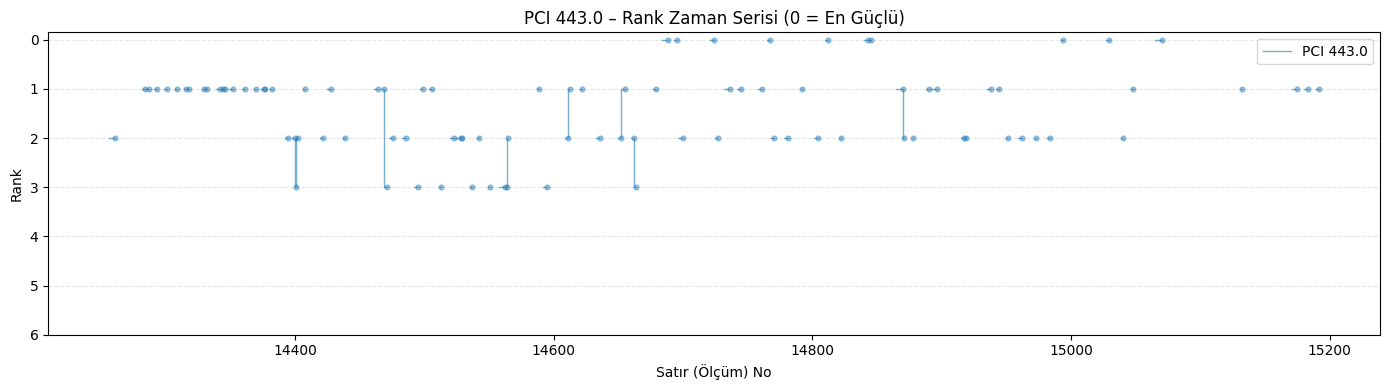

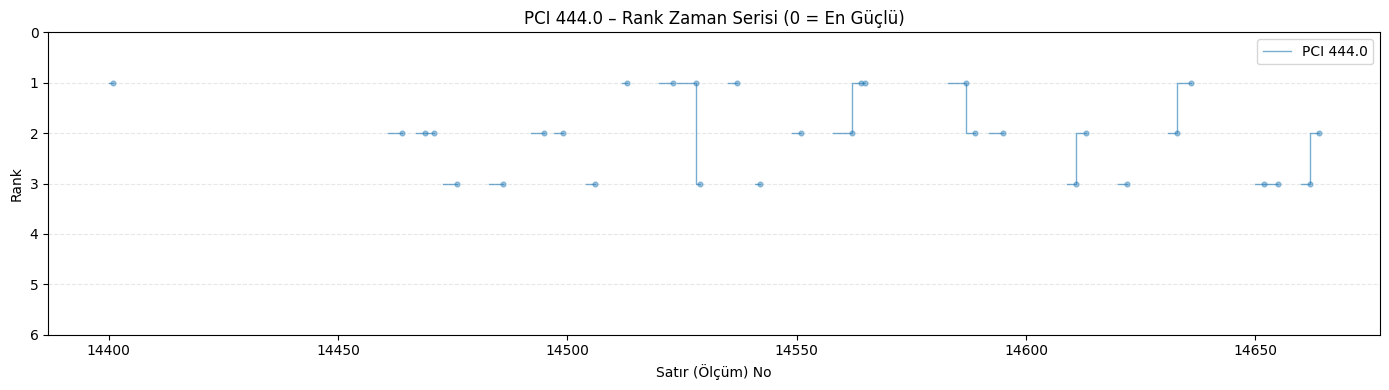

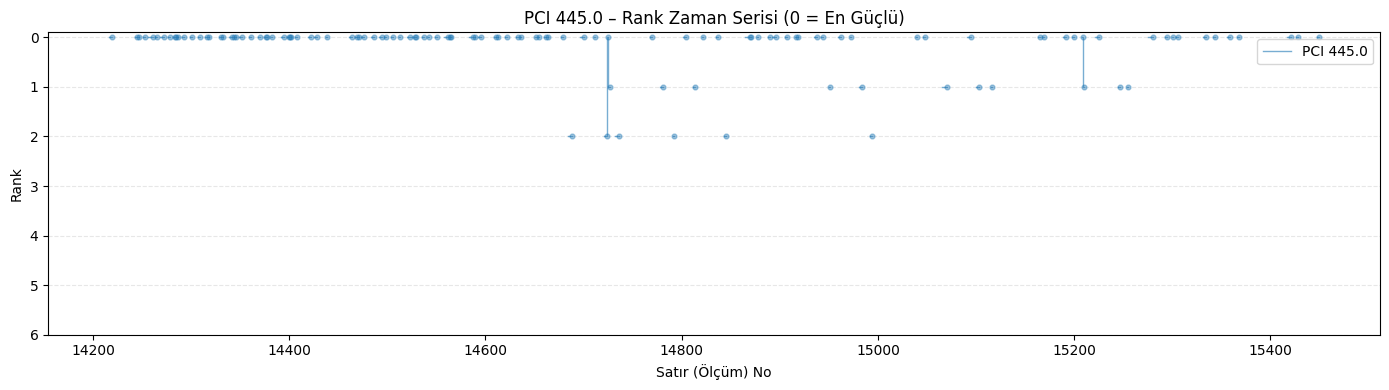

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------------
# 1. PCI kolonlarını seç
# ---------------------------------------------------------------
pci_cols = [
    "NR_Scan_PCI_SortedBy_RSRP_0", "NR_Scan_PCI_SortedBy_RSRP_1",
    "NR_Scan_PCI_SortedBy_RSRP_2", "NR_Scan_PCI_SortedBy_RSRP_3",
    "NR_Scan_PCI_SortedBy_RSRP_4", "NR_Scan_PCI_SortedBy_RSRP_5",
    "NR_Scan_PCI_SortedBy_RSRP_6"
]
pci_cols = [c for c in pci_cols if c in df_scanner.columns]

# ---------------------------------------------------------------
# 2. Long form: her PCI + rank bilgisi tek satırda
# ---------------------------------------------------------------
df_long = (
    df_scanner
    .reset_index(names="row_idx")
    .melt(id_vars="row_idx", value_vars=pci_cols,
          var_name="rank_col", value_name="pci")
    .dropna(subset=["pci"])
)
df_long["rank"] = df_long["rank_col"].str.extract(r"_(\d)$").astype(int)
df_long = df_long[["row_idx", "pci", "rank"]]

# ---------------------------------------------------------------
# 3. Pivot: her PCI bir kolon, hücrelerde "kaçıncı sırada yer aldı"
# ---------------------------------------------------------------
df_pivot = df_long.pivot(index="row_idx", columns="pci", values="rank").sort_index(axis=1)

# ---------------------------------------------------------------
# 4. Her PCI için okunaklı çizgi grafiği üret
# ---------------------------------------------------------------
for pci in df_pivot.columns:
    fig, ax = plt.subplots(figsize=(14, 4))

    # Çizgi (basamaklı) ve noktalar (şeffaf)
    ax.plot(
        df_pivot.index,
        df_pivot[pci],
        drawstyle="steps-pre",
        linewidth=1.0,
        alpha=0.6,
        label=f"PCI {pci}"
    )
    ax.scatter(
        df_pivot.index,
        df_pivot[pci],
        s=12,
        alpha=0.4,
        zorder=3
    )

    # Biçimlendirme
    ax.set_title(f"PCI {pci} – Rank Zaman Serisi (0 = En Güçlü)")
    ax.set_xlabel("Satır (Ölçüm) No")
    ax.set_ylabel("Rank")
    ax.set_yticks(range(7))
    ax.invert_yaxis()
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [16]:
import pandas as pd
import plotly.graph_objects as go
from plotly.colors import qualitative

# --- 1. Veri dönüşümü ---
pci_cols = [
    "NR_Scan_PCI_SortedBy_RSRP_0", "NR_Scan_PCI_SortedBy_RSRP_1",
    "NR_Scan_PCI_SortedBy_RSRP_2", "NR_Scan_PCI_SortedBy_RSRP_3",
    "NR_Scan_PCI_SortedBy_RSRP_4", "NR_Scan_PCI_SortedBy_RSRP_5",
    "NR_Scan_PCI_SortedBy_RSRP_6"
]
pci_cols = [c for c in pci_cols if c in df_scanner.columns]

df_long = (
    df_scanner.reset_index(names="row_idx")
              .melt(id_vars="row_idx", value_vars=pci_cols,
                    var_name="rank_col", value_name="pci")
              .dropna(subset=["pci"])
)
df_long["rank"] = df_long["rank_col"].str.extract(r'_(\d)$').astype(int)
df_pivot = df_long.pivot(index="row_idx", columns="pci", values="rank").sort_index(axis=1)
pcis = df_pivot.columns.tolist()

# --- 2. Marker-only figür, uzak renklerle ---
fig = go.Figure()

# Uzak renk paleti (24 adet); fazla PCI varsa döngü tekrarlar
color_pool = qualitative.Dark24

for i, pci in enumerate(pcis):
    fig.add_trace(
        go.Scatter(
            x=df_pivot.index,
            y=df_pivot[pci],
            mode="markers",
            name=str(pci),
            marker=dict(size=6, opacity=0.6, color=color_pool[i % len(color_pool)]),
            hovertemplate="Row: %{x}<br>Rank: %{y}<br>PCI: "+str(pci)+"<extra></extra>",
        )
    )

fig.update_layout(
    title="PCI Rank vs Row (Marker Only – Uzak Renkler)",
    xaxis_title="Row (Measurement Index)",
    yaxis_title="Rank (0 = Strongest)",
    yaxis=dict(autorange="reversed", tickmode="linear", dtick=1),
    hovermode="x unified",
    autosize=True,
    margin=dict(t=80, b=80, l=60, r=30),
    legend=dict(title="PCI", orientation="v", y=1, x=1.02),
)

# --- 3. HTML olarak kaydet ---
fig.write_html(
    "pci_rank_markers_colored.html",
    include_plotlyjs="cdn",
    full_html=True,
    config={"responsive": True},
    default_height="100%",
    default_width="100%"
)

print("✓ Kontrastlı renklerle kaydedildi → pci_rank_markers_colored.html")


✓ Kontrastlı renklerle kaydedildi → pci_rank_markers_colored.html
